In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import seaborn as sns
from ast import literal_eval

In [2]:
def plot_comparison_figures(all_df, sweep_param_name):
    """
    绘制对比 Precision/Recall 和 Index/Candidate 堆叠 Accesses 的总图。
    """
    print("\n# ==========================================================================")
    print("=== FINAL PART: Plotting Comparison Figures ===")
    print("=========================================================================#")

    if all_df.empty:
        print("所有实验结果为空，无法生成总对比图。")
        return

    # --- 图 1: Precision 和 Recall 对比图 (保持不变) ---
    plt.figure(figsize=(12, 8))
    
    # 获取唯一的 maxDist 值用于设置 x 轴刻度
    x_ticks = all_df[sweep_param_name].unique()
    methods = all_df['method'].unique()
    num_methods = len(methods)
    
    styles = {
        'sae':    {'marker': 'o', 'color': 'tab:blue'},
        'anchor': {'marker': 's', 'color': 'tab:green'},
        'DNA-Geofence':  {'marker': '^', 'color': 'tab:red'}
    }

    # 1. 绘制 Precision
    ax1 = plt.gca()
    for method in methods:
        df_method = all_df[all_df['method'] == method]
        style = styles.get(method, {})
        ax1.plot(df_method[sweep_param_name], df_method["avg_precision"], 
                 label=f'{method.upper()} Precision', 
                 linestyle='-', **style)

    # 2. 绘制 Recall
    for method in methods:
        df_method = all_df[all_df['method'] == method]
        style = styles.get(method, {})
        ax1.plot(df_method[sweep_param_name], df_method["avg_recall"], 
                 label=f'{method.upper()} Recall', 
                 linestyle='--', **style)

    ax1.set_xlabel("Max Distance (Error Tolerance)")
    ax1.set_ylabel("Average Metric Value (Precision/Recall)")
    ax1.set_title("Comparison of Precision and Recall Across Methods")
    ax1.legend(loc='lower right')
    ax1.grid(True)
    ax1.set_xticks(x_ticks) # 设置 X 轴刻度
    
    fig_pr_comp_path = "./fig/comparison_precision_recall_maxDist.png"
    plt.show()
    # plt.savefig(fig_pr_comp_path)
    print(f"总 Precision/Recall 对比图已保存至: {fig_pr_comp_path}")
    plt.close()

    # --- 图 2: Index/Candidate 堆叠 Accesses 分组柱状图 (修改部分) ---
    if 'index_accesses' in all_df.columns and 'candidate_accesses' in all_df.columns:
        plt.figure(figsize=(12, 6))
        ax2 = plt.gca()
        
        max_dists = all_df[sweep_param_name].unique()
        
        # 动态计算柱子宽度
        bar_width = 0.8 / num_methods # 0.8 是组内总宽度
        
        # 定义颜色的映射
        method_colors = {
            'sae': 'tab:blue',
            'anchor': 'tab:green',
            'DNA-Geofence': 'tab:red'
        }
        
        # 遍历每个 maxDist 作为一组
        for i, max_d in enumerate(max_dists):
            df_group = all_df[all_df[sweep_param_name] == max_d].copy()
            
            # 确保方法按固定顺序排列，以便柱子顺序一致
            df_group['method'] = pd.Categorical(df_group['method'], categories=methods, ordered=True)
            df_group = df_group.sort_values('method')
            
            # 计算组内起始位置 (用于左移/右移)
            center_x = i
            group_start_x = center_x - (bar_width * num_methods / 2) + (bar_width / 2)
            
            # 遍历组内的每个方法绘制堆叠柱子
            for j, method in enumerate(df_group['method']):
                data = df_group[df_group['method'] == method].iloc[0]
                
                index_count = data['index_accesses']
                candidate_count = data['candidate_accesses']
                
                bar_pos = group_start_x + j * bar_width
                
                # 绘制 Index Accesses (底部)
                ax2.bar(bar_pos, index_count, bar_width, 
                        color=method_colors[method], alpha=0.9, 
                        label=f'{method.upper()} Index' if i == 0 else "", # 只在第一个 maxDist 组添加标签
                        edgecolor='black')
                
                # 绘制 Candidate Accesses (堆叠在 Index 之上)
                ax2.bar(bar_pos, candidate_count, bar_width, 
                        bottom=index_count, 
                        color=method_colors[method], alpha=0.5, 
                        label=f'{method.upper()} Candidate' if i == 0 else "", 
                        edgecolor='black')

        # 设置 X 轴刻度：显示 maxDist 值，并将其放置在分组的中心
        ax2.set_xticks(range(len(max_dists)))
        ax2.set_xticklabels(max_dists)
        
        # # 设置 Y 轴为对数刻度 (Log Scale)
        ax2.set_yscale('log')
        
        ax2.set_xlabel("Max Distance (Error Tolerance)")
        ax2.set_ylabel("Accesses Count (Index + Candidate, Log Scale)")
        ax2.set_title("Comparison of Index/Candidate Stacked Accesses Across Methods (Log Scale)")
        
        # 创建自定义图例：使用两个循环，一个用于 Index（深色），一个用于 Candidate（浅色）
        legend_handles = []
        for method in methods:
            color = method_colors[method]
            # Index (深色)
            legend_handles.append(plt.Rectangle((0, 0), 1, 1, fc=color, alpha=0.9, label=f'{method.upper()} Index'))
            # Candidate (浅色)
            legend_handles.append(plt.Rectangle((0, 0), 1, 1, fc=color, alpha=0.5, label=f'{method.upper()} Candidate'))

        ax2.legend(handles=legend_handles, loc='upper left', bbox_to_anchor=(1.01, 1))
        ax2.grid(axis='y', linestyle=':', alpha=0.7)
        ax2.legend(loc='upper left')
        
        plt.tight_layout(rect=[0, 0, 0.95, 1]) # 调整布局以适应图例
        
        fig_access_comp_path = "./fig/comparison_accesses_grouped_stacked_log_maxDist.png"
        plt.show()
        # plt.savefig(fig_access_comp_path)
        print(f"总 Accesses 堆叠分组柱状图（Log Y）已保存至: {fig_access_comp_path}")
        plt.close()
    else:
        print("⚠️ 无法计算 Accesses，跳过 Accesses 对比图。")

    if 'distances' in all_df.columns:
        # 筛选出那些 'distances' 列表不为空的行，并使用 .copy() 明确操作一个副本
        df_with_dist = all_df[all_df['distances'].apply(lambda x: x is not None and len(str(x).strip()) > 0)].copy()

        if not df_with_dist.empty:
            
            # 0. 【修正】转换：将字符串形式的列表安全地转换为 Python 列表对象
            try:
                # 明确使用 .loc 进行赋值，避免 SettingWithCopyWarning
                # 假设 df_with_dist['distances'] 中的数据是字符串
                df_with_dist.loc[:, 'distances'] = df_with_dist['distances'].apply(literal_eval)
            except (ValueError, TypeError) as e:
                print(f"⚠️ 无法使用 literal_eval 转换 'distances' 列: {e}")
                # 如果转换失败，可以直接返回或跳过
                # return
                pass 

            # A. 数据转换：展开 (Explode)
            df_long = df_with_dist.explode('distances')
            def add_small_jitter(x):
                # 全为同一个值或方差为 0
                # if x.nunique() <= 1:
                #     return x + 10
                return x+1

            # B. 清理和类型转换
            df_long = df_long.rename(columns={
                'distances': 'distance_value',
                sweep_param_name: 'Max Distance'
            })
            df_long['distance_value'] = df_long.groupby('method')['distance_value'].transform(add_small_jitter)
            
            # 将展开后的 'distance_value' 转换为数值类型
            df_long['distance_value'] = pd.to_numeric(df_long['distance_value'], errors='coerce')
            # 删除转换失败的（NaN）行
            df_long.dropna(subset=['distance_value'], inplace=True)
            df_long['Max Distance'] = df_long['Max Distance'].astype('category')
            
            # 重点：确保 'method' 也是分类类型，有助于绘图顺序
            df_long['method'] = df_long['method'].astype('category')

            # C. 绘图：改良小提琴图 + 抖动点 + 对数 y 轴（推荐最终版）

            # --- 准备顺序，确保一致性（如果 Max Distance 是 category）
            order = list(df_long['Max Distance'].cat.categories) if 'Max Distance' in df_long.columns and pd.api.types.is_categorical_dtype(df_long['Max Distance']) else sorted(df_long['Max Distance'].unique(), key=lambda x: (str(x)))
            hue_order = list(df_long['method'].cat.categories) if 'method' in df_long.columns and pd.api.types.is_categorical_dtype(df_long['method']) else sorted(df_long['method'].unique(), key=lambda x: str(x))

            plt.figure(figsize=(8, 6))
            ax = plt.gca()

            # 1) 小提琴（主负责 hue 和 dodge）
            sns.violinplot(
                data=df_long,
                x='Max Distance',
                y='distance_value',
                hue='method',
                order=order,
                hue_order=hue_order,
                palette=method_colors,
                alpha=0.7,
                inner=None,
                bw=0.25,
                cut=0,
                scale='count',
                dodge=True,
                width=0.8,   # 控制每组 violins 的宽度
                ax=ax
            )

            # 2) 抖动散点（也使用相同的 hue & dodge，这样点会对齐在对应 violins 上）
            sns.stripplot(
                data=df_long,
                x='Max Distance',
                y='distance_value',
                hue='method',
                order=order,
                hue_order=hue_order,
                palette=method_colors,
                dodge=True,
                jitter=0.25,
                alpha=0.7,
                size=2,
                linewidth=0,
                ax=ax
            )

            # 3) 对数坐标与 y 范围（同你原来逻辑）
            ax.set_yscale('log')
            positive_min = df_long.loc[df_long['distance_value'] > 0, 'distance_value'].min()
            if pd.notna(positive_min):
                ymin = positive_min * 0.5
            else:
                ymin = df_long['distance_value'].min() if df_long['distance_value'].min() > 0 else 1e-3
            ax.set_ylim(ymin, df_long['distance_value'].max() * 1.2)

            # 4) 辅助线（log 上的参考线）
            for y in [1, 10, 50, 100, 200]:
                if ymin < y < df_long['distance_value'].max():
                    ax.axhline(y, color='gray', linewidth=0.8, linestyle='--', alpha=0.6)

            # 5) 去掉重复 legend：从现有 handles/labels 中去重（保留第一个出现的）
            handles, labels = ax.get_legend_handles_labels()
            # handles/labels 来自两次绘图（violin + stripplot），按 label 去重保留首个
            unique = {}
            for h, l in zip(handles, labels):
                if l not in unique:
                    unique[l] = h
            ax.legend(unique.values(), unique.keys(), title='Method', loc='upper left')

            # 6) 完整边框
            sns.despine(offset=0, trim=False)
            for spine in ax.spines.values():
                spine.set_visible(True)
                spine.set_linewidth(1.0)

            # 7) 标题与坐标
            ax.set_title("Candidate Distance Distributions", fontsize=16, pad=12)
            ax.set_xlabel(sweep_param_name.replace('_', ' ').title())
            ax.set_ylabel("Candidate Distance Value (log scale)")

            # 美化刻度格式
            ax.yaxis.set_major_formatter(plt.ScalarFormatter())
            ax.tick_params(axis='y', which='minor', left=False)

            plt.tight_layout()
            plt.show()

        
        else:
            print("⚠️ 'distances' 列中没有有效数据。")
    else:
        print("⚠️ 无法找到 'distances' 列，跳过小提琴图。")

    # import ptitprince as pt
    # pt.RainCloud(data=df_long, x='Max Distance', y='distance_value', hue='method',
    #          palette=method_colors, bw=0.2, width_viol=0.7,
    #          orient='v', alpha=0.65, dodge=True, move=0.2)
    # plt.title("Raincloud Plot: Violin + Box + Beeswarm Points")
    # plt.show()

    # g = sns.catplot(data=df_long, x='Max Distance', y='distance_value', 
    #             hue='method', kind='strip', palette=method_colors,
    #             jitter=0.3, alpha=0.6, dodge=True, height=6, aspect=2)

    # # 再叠加显示最常见的值（众数）
    # for cat in df_long['Max Distance'].cat.categories:
    #     for i, method in enumerate(df_long['method'].unique()):
    #         subset = df_long[(df_long['Max Distance']==cat) & (df_long['method']==method)]
    #         if len(subset) > 0:
    #             mode_val = subset['distance_value'].mode().iloc[0] if len(subset['distance_value'].mode())>0 else np.nan
    #             count = (subset['distance_value'] == mode_val).sum()
    #             total = len(subset)
    #             g.ax.text(cat + (i-0.5)*0.3, mode_val, f'{mode_val}\n(n={count})',
    #                     ha='center', va='bottom', fontsize=8, color=method_colors[method])        
        
    return


# ==========================================================================
=== FINAL PART: Plotting Comparison Figures ===
=========================================================================#


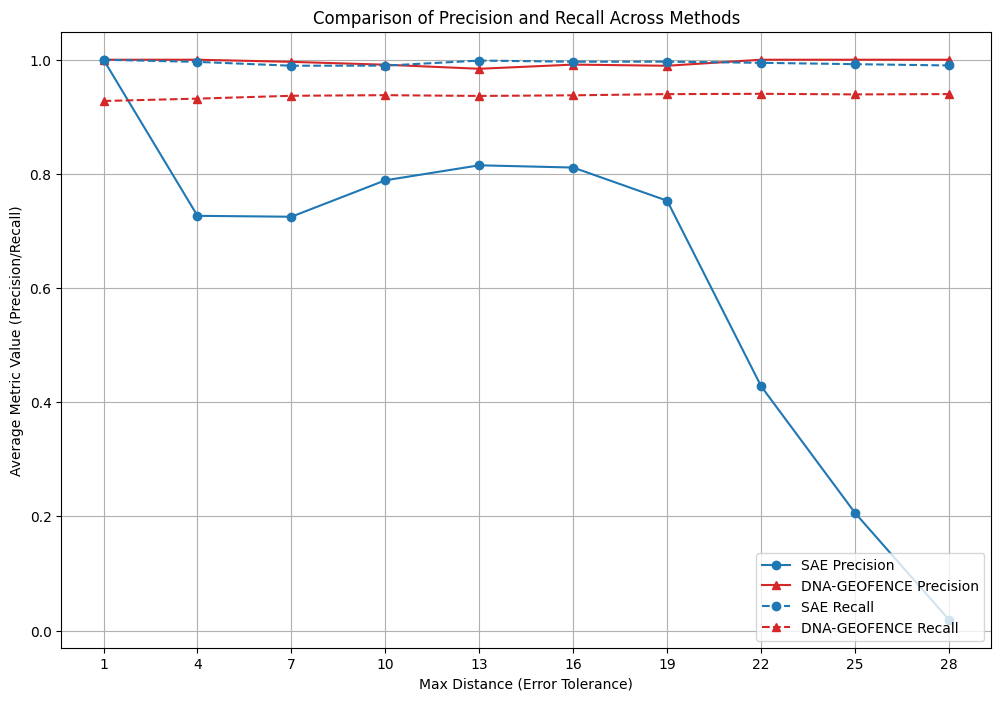

总 Precision/Recall 对比图已保存至: ./fig/comparison_precision_recall_maxDist.png


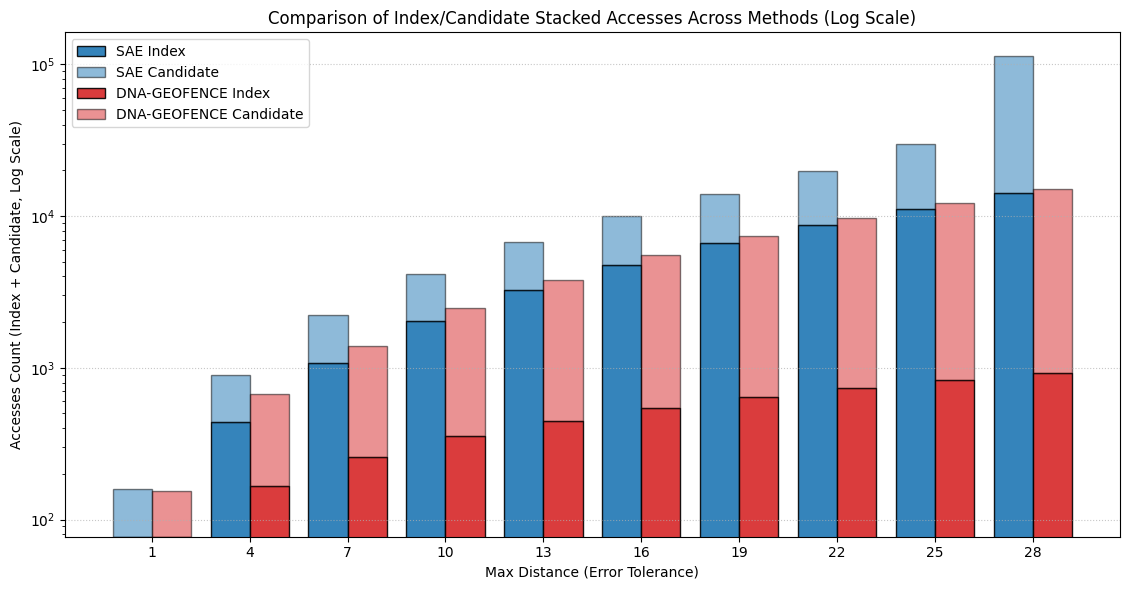

总 Accesses 堆叠分组柱状图（Log Y）已保存至: ./fig/comparison_accesses_grouped_stacked_log_maxDist.png


/tmp/ipykernel_1198491/1570889188.py:186: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  order = list(df_long['Max Distance'].cat.categories) if 'Max Distance' in df_long.columns and pd.api.types.is_categorical_dtype(df_long['Max Distance']) else sorted(df_long['Max Distance'].unique(), key=lambda x: (str(x)))
/tmp/ipykernel_1198491/1570889188.py:187: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  hue_order = list(df_long['method'].cat.categories) if 'method' in df_long.columns and pd.api.types.is_categorical_dtype(df_long['method']) else sorted(df_long['method'].unique(), key=lambda x: str(x))
/tmp/ipykernel_1198491/1570889188.py:193: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='count'` for the same effect.
  sns.violinplo

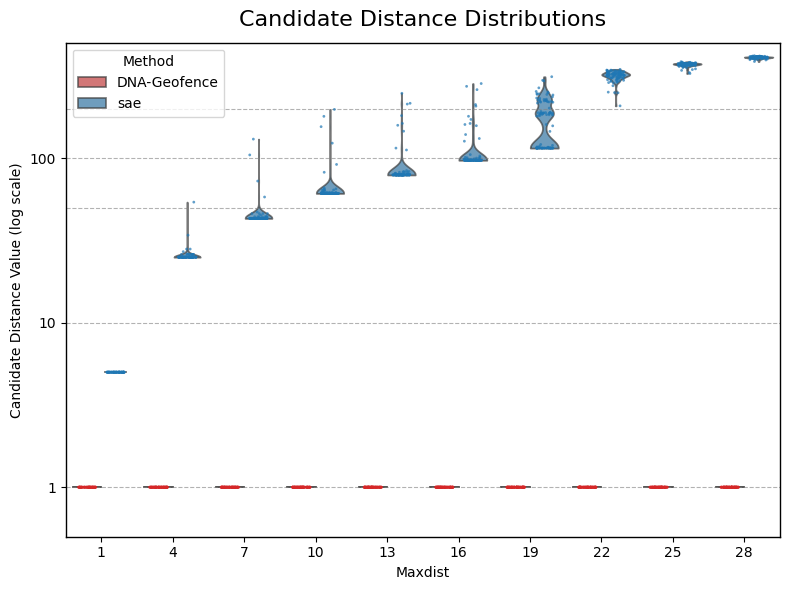

In [3]:
final_comparison_df = pd.read_csv("./test/csv/comparison_distance1_30_sae_mt.csv")
# final_comparison_df = final_comparison_df.iloc[range(0, len(final_comparison_df), 2), :]
plot_comparison_figures(final_comparison_df, "maxDist")